#MONTE CARLO TREE SEARCH (MCTS)

In [ ]:
#@title Define Mermaid Ink
#https://github.com/jihchi/mermaid.ink

import base64
import io
import requests
import IPython

def mermaid(graph):
  mermaidInkUrl = 'https://mermaid.ink/svg/'
  display(
    IPython.display.HTML(
      io.BytesIO( # generate svg on the fly
        requests.get(
          mermaidInkUrl +
          base64.b64encode(
            graph.encode('ascii')
          ).decode("ascii")
        ).content
      ).read().decode('utf-8')
    )
  )



This implementation is based on John Levine's tutorial on youtube: https://www.youtube.com/watch?v=UXW2yZndl7U


Monte Carlo Tree Search

Monte Carlo Tree Search works in 4 phases

1. Tree traversal
 - UCB1 - Upper Confidence Bound 1 applied to trees

 - $UCB1(S_i) = \bar{V_i} + C\sqrt{\frac{ln{N}}{n_i}}$
 - In the below example $C=2$

2. Node expansion
 - where you add extra nodes into the tree

3. Rollout (random simulation)
 - where you do a **random simulation** or work on the problem you are solving in order to find the **value**

4. Backpropagation
 - take the **value** found in the rollout, put that into a proper place in the tree backtrace upward from the node, level by level, up to the root node.


 Exploitation term $\bar{V_i}$

 Exploration term $\sqrt{\frac{ln{N}}{n_i}}$

In [ ]:
#@title flow chart
#@markdown step 1, 2 flow chart
mermaid('''flowchart LR
    Start("Start") --> CurrentS0["Current = S_0 "]
    CurrentS0 --> IsCurrentALeafNode{"is current a leaf node?"}
    IsCurrentALeafNode --> |No| AssignCurrentChildNode["Current = child<br/>node of Current<br/>that maximizes<br/> UCB1(  S_i  ) "]
    AssignCurrentChildNode --> IsCurrentALeafNode
    IsCurrentALeafNode --> |Yes| IsTheValueForCurrent0{"is the n_i value<br/>for current 0 ?"}
    IsTheValueForCurrent0 --> |NEVER| Rollout["ROLLOUT"]
    IsTheValueForCurrent0 --> |HAS| ExpandTheTree["for each available <br/> action from Current <br/> S_i, add a new<br/>state to the tree"]
    ExpandTheTree --> AssignCurrentNode["Current = first<br/>new child node"]
    AssignCurrentNode --> Rollout''')

start with $S_0$ as the initial state being the current state

is current a leaf node?

 - **NO**
   - going to explore by calculating the ucb1 value of each of the states, choose the one that maximizes that value
   - calculate $UCB1(...)$ for each of the child states $S_i$ and then you select the node that maximizes that formula
   - keep doing this and going around until you get to a leaf node in the tree
 - **YES**
   - how many times has it been sampled ?
   - **NEVER** been sampled
     - simply do a rollout from there
   - **HAS** been sampled before
     - this is where you add new nodes into the tree
     - for each available action from the current state you add a new state to the tree and then you let current be the first of those new child nodes
     - rollout

Rollout Process $S_i$
  - loop forever
    - if $S_i$ is a terminal state
      - return $value(S_i)$
    - $A_i = random( available\ actions ( S_i ) ) $
    - $S_i = Simulate ( A_i, S_i ) $



iteration 0
roleout(S[1]) ~ 20.0
back_propagate: S[1]
back_propagate: S[0]


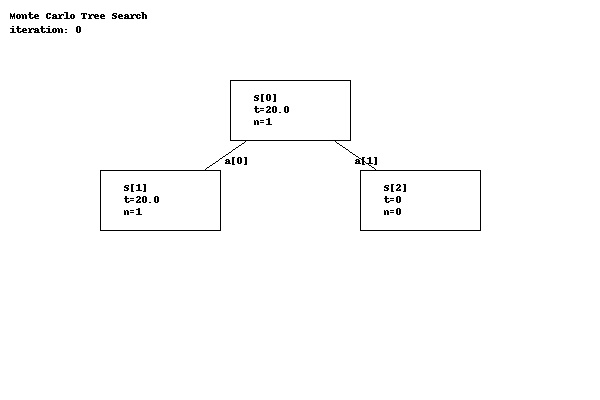

iteration 1
roleout(S[2]) ~ 10.0
back_propagate: S[2]
back_propagate: S[0]


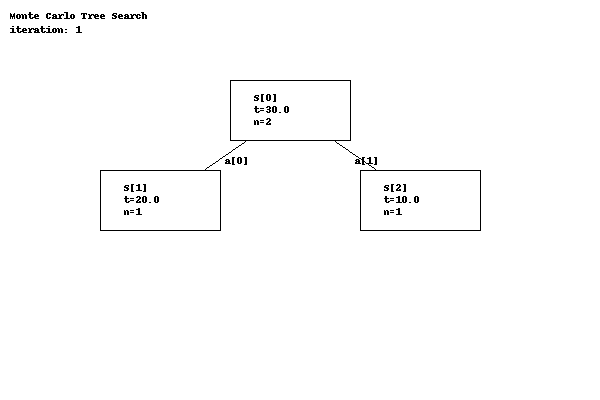

iteration 2
roleout(S[3]) ~ 0.0
back_propagate: S[3]
back_propagate: S[1]
back_propagate: S[0]


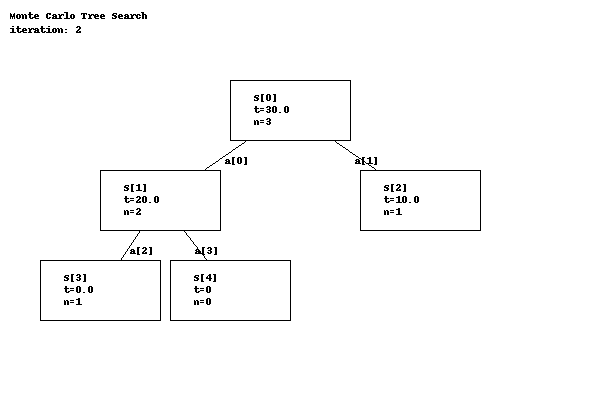

iteration 3
roleout(S[5]) ~ 14.0
back_propagate: S[5]
back_propagate: S[2]
back_propagate: S[0]


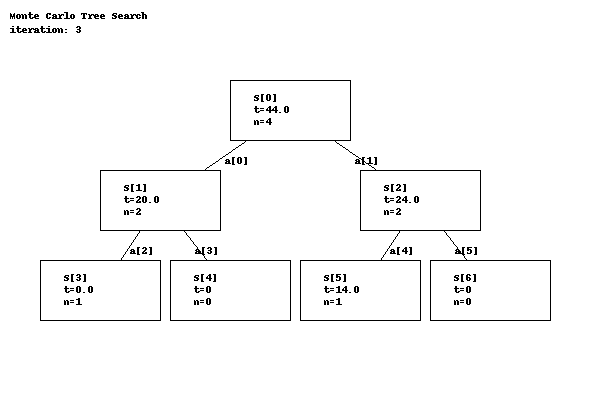

In [7]:
import json
import math
import random

from PIL import Image, ImageDraw
from IPython.display import display

# positions for the binary tree nodes
positions = {
    0: (190, 80),
    1: ( 60, 170),
    2: (320, 170),
    3: (0, 260),
    4: (130, 260),
    5: (260, 260),
    6: (390, 260)
}

# values for each rollout
values = {
    1: 20.,
    2: 10.,
    3: 0.,
    5: 14.,
}

class Action:
    def __init__(self):
        pass

def argmax(x):
    return max(range(len(x)), key=lambda i: x[i])

class MonteCarloTreeState:
    n_state = 0
    def __init__(self, C=2):
        self.state_id = MonteCarloTreeState.n_state
        MonteCarloTreeState.n_state += 1
        self.value = None
        self.t = 0 # total score
        self.n = 0 # number of visits
        self.children = []
        self.actions = [Action(), Action()]
        self.parent = None
        self.C = C # exploration parameter

    def back_propagate(self, value):
        # handle itself and everything upward
        current_mct_state = self
        while current_mct_state != None:
            current_mct_state.t += value
            current_mct_state.n += 1 # number of visits + 1
            print(f"back_propagate: S[{current_mct_state.state_id}]")
            current_mct_state = current_mct_state.parent

    def is_leaf_node(self):
        return len(self.children) == 0

    def rollout(self):
        if self.state_id in values:
            self.value = values[self.state_id]
        else:
            self.value = random.randint(5, 10)
        print(f"roleout(S[{self.state_id}]) ~ {self.value}")
        return self.value

    def get_s0(self):
        state = self
        while state.parent != None:
            state = state.parent
        return state

    def UBC1(self):
        if self.n == 0:
            return float('inf')
        else:
            N = self.get_s0().n # means the total sample times comes from s0.n
            exploitation_term = float(self.t) / float(self.n)
            exploration_term = math.sqrt(math.log(float(N)) / float(self.n))
        return exploitation_term + self.C * exploration_term

    def __repl__(self):
        return json.dumps({
            "id": id(self),
            "state_id": self.state_id,
            "value": self.value,
            "t": self.t,
            "n": self.n
        }, indent=2)

    def __str__(self):
        return self.__repl__()

class MonteCarloTreeSearch:
    def __init__(self):
        self.s0 = None # start state
        self.current = None # traverse postion

        # used for visualization
        self._image = None
        self._a_id = 0
        self.iteration = 0

    def expand_nodes(self, mct_state):
        available_actions = mct_state.actions
        for i in range(len(available_actions)):
            state = MonteCarloTreeState()
            state.parent = mct_state
            mct_state.children.append(state)

    def search(self):
        self.s0 = MonteCarloTreeState()
        self.current = self.s0
        self.expand_nodes(self.s0)

        for i in range(4):
            self.current = self.s0
            self.iteration = i
            print(f"iteration {self.iteration}")
            self.tree_traverse()

            self._image = None
            self.draw_states(self.s0, self.draw_state)
            display(self._image)

    def tree_traverse(self):
        # is current a leaf node?
        while not self.current.is_leaf_node():
            # calculate all children UBC1
            ubc1s = []
            for i in range(len(self.current.children)):
                ubc1s.append(self.current.children[i].UBC1())
            self.current = self.current.children[argmax(ubc1s)]

        if self.current.is_leaf_node():
            # is the n_i value for current 0 ?
            #if self.current.n == 0:
            #    # never been sampled
            #    pass
            if self.current.n != 0:
                # has been sampled before
                self.expand_nodes(self.current)
                self.current = self.current.children[0]
            self.current.rollout()
            self.current.back_propagate(self.current.value)

    def draw_states(self, state, draw_state_func):
        draw_state_func(state)
        for i in range(len(state.children)):
            self.draw_states(state.children[i], draw_state_func)

    def draw_state(self, state):
        if self._image == None:
            self._image = Image.new("RGB", (600,400), (255,255,255))
            self._a_id = 0 # reset the action id

        x_offset, y_offset = 40, 0
        state_id = state.state_id


        width, height = 120, 60
        draw = ImageDraw.Draw(self._image)
        draw.text((10,10), f"Monte Carlo Tree Search", fill=(0,0,0))
        draw.text((10,24), f"iteration: {self.iteration}", fill=(0,0,0))
        x0, y0 = positions[state_id]
        x0 += x_offset

        if len(state.children) >0:
            cx0, cy0 = positions[state_id]
            cx0 += x_offset
            cx0 += width // 2
            cy0 += height // 2
            for i in range(len(state.children)):
                cx1, cy1 = positions[state.children[i].state_id]
                cx1 += x_offset
                cx1 += width // 2
                cy1 += height // 2
                draw.line((cx0,cy0, cx1, cy1), fill=(0,0,0))
                draw.text(xy=((cx0+cx1)//2, (cy0+cy1)//2), fill=(0,0,0), text=f"a[{self._a_id}]")
                self._a_id += 1

        draw.rectangle((x0, y0, x0+width, y0+height),fill=(255,255,255), outline=(0,0,0))

        draw.text(xy=(x0+24, y0+12), fill=(0,0,0), text=f"S[{state.state_id}]")
        draw.text(xy=(x0+24, y0+24), fill=(0,0,0), text=f"t={state.t}")
        draw.text(xy=(x0+24, y0+36), fill=(0,0,0), text=f"n={state.n}")

MonteCarloTreeSearch().search()
